# Matrices, Part 2

Notebook ini merangkum Chapter 6 dari *Practical Linear Algebra for Data Science*. Chapter ini melanjutkan pembahasan matrix dengan konsep yang lebih mendasar untuk advanced linear algebra, yaitu **matrix norms**, **matrix spaces**, **rank**, **determinant**, dan **characteristic polynomial**.

Gaya notebook dibuat ringkas seperti Chapter 3: tidak terlalu panjang, tetapi tetap mencakup teori utama, rumus penting, dan contoh kode yang relevan dengan isi chapter.

## Tujuan Pembelajaran

- Memahami konsep matrix norm, terutama Frobenius norm.
- Menjelaskan hubungan trace dan Frobenius norm.
- Memahami column space, row space, dan null space.
- Menjelaskan konsep rank dan hubungannya dengan linear independence.
- Mengenali rank pada special matrices.
- Memahami pengaruh shifting terhadap rank matrix.
- Menentukan apakah sebuah vector berada dalam column space matrix.
- Memahami determinant sebagai nilai yang hanya dimiliki square matrix.
- Menjelaskan hubungan determinant dengan reduced-rank matrix.
- Mengenal characteristic polynomial sebagai pengantar eigenvalues.

## Ringkasan Chapter

Chapter ini memperluas pembahasan matrix dari chapter sebelumnya. Jika Chapter 5 berfokus pada operasi dasar matrix, maka Chapter 6 mulai membahas properti yang lebih dalam seperti norm, space, rank, dan determinant.

Bagian awal membahas matrix norms. Matrix norm menghasilkan satu angka yang menggambarkan matrix. Chapter ini berfokus pada element-wise norm, khususnya Frobenius norm, yaitu perluasan langsung dari Euclidean norm pada vector.

Bagian berikutnya membahas matrix spaces, yaitu column space, row space, dan null space. Ketiganya berkaitan erat dengan linear weighted combination dari bagian-bagian matrix. Column space berisi seluruh kombinasi linear dari column vectors, row space berisi kombinasi linear dari row vectors, sedangkan null space berisi vector nonzero yang jika dikalikan dengan matrix menghasilkan zeros vector.

Setelah itu, chapter membahas rank. Rank adalah bilangan nonnegatif yang menunjukkan jumlah maksimum row atau column yang linearly independent. Rank juga berhubungan dengan dimensionality dari column space dan row space. Chapter ini juga menjelaskan rank pada special matrices, rank dari matrix yang dijumlahkan atau dikalikan, serta rank pada shifted matrix.

Bagian akhir membahas determinant dan characteristic polynomial. Determinant hanya didefinisikan untuk square matrix dan bernilai nol untuk reduced-rank matrix. Characteristic polynomial diperkenalkan sebagai cara menghubungkan determinant dengan eigenvalues, yang akan dibahas lebih dalam pada chapter berikutnya.

## Struktur Pembahasan Chapter

| Bagian | Inti Pembahasan |
|---|---|
| Matrix Norms | Matrix norm menghasilkan satu angka yang menggambarkan matrix. |
| Trace and Frobenius Norm | Frobenius norm dapat dihitung melalui trace dari $A^TA$. |
| Matrix Spaces | Column space, row space, dan null space berasal dari linear weighted combinations. |
| Rank | Rank menunjukkan jumlah dimensi informasi dalam matrix. |
| Rank Applications | Rank dapat digunakan untuk mengecek column space dan linear independence. |
| Determinant | Determinant hanya ada pada square matrix dan bernilai nol untuk singular matrix. |
| Characteristic Polynomial | Determinant dari shifted matrix membentuk polynomial yang berkaitan dengan eigenvalues. |

## Persiapan Library

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt

try:
    import scipy.linalg
    SCIPY_AVAILABLE = True
except Exception:
    SCIPY_AVAILABLE = False

np.random.seed(2024)

## Matrix Norms

Matrix norm mirip dengan vector norm karena sama-sama menghasilkan satu angka untuk menggambarkan suatu objek. Namun, matrix memiliki beberapa jenis norm. Chapter ini membagi matrix norm menjadi dua kelompok besar:

| Jenis Norm | Penjelasan |
|---|---|
| Element-wise / entry-wise norm | Dihitung berdasarkan elemen-elemen individual matrix. |
| Induced norm | Mengukur seberapa besar matrix menskalakan vector saat transformasi. |

Chapter ini berfokus pada element-wise norm, terutama Frobenius norm.

## Rumus Frobenius Norm

Frobenius norm adalah perluasan langsung dari Euclidean norm pada vector.

$$
\|A\|_F =
\sqrt{
\sum_{i=1}^{M}
\sum_{j=1}^{N}
a_{ij}^{2}
}
$$

Keterangan:

- $A$ = matrix
- $\|A\|_F$ = Frobenius norm dari matrix $A$
- $a_{ij}$ = elemen matrix pada row ke-$i$ dan column ke-$j$
- $M$ = jumlah rows
- $N$ = jumlah columns

Frobenius norm juga disebut Euclidean norm atau $\ell_2$ norm untuk matrix.

## Rumus General Element-wise p-Norm

Chapter juga memperkenalkan bentuk umum element-wise p-norm.

$$
\|A\|_p =
\left(
\sum_{i=1}^{M}
\sum_{j=1}^{N}
|a_{ij}|^p
\right)^{1/p}
$$

Keterangan:

- $p$ = parameter norm
- Jika $p=2$, maka rumus menjadi Frobenius norm.
- Norm ini mencerminkan besar kecilnya elemen-elemen matrix.

In [2]:
A = np.array([
    [1, 2, 3],
    [4, 5, 6]
])

fro_manual = np.sqrt(np.sum(A**2))
fro_numpy = np.linalg.norm(A, "fro")

print("Frobenius norm manual:", fro_manual)
print("Frobenius norm NumPy :", fro_numpy)

Frobenius norm manual: 9.539392014169456
Frobenius norm NumPy : 9.539392014169456


## Frobenius Distance

Frobenius norm juga dapat digunakan sebagai ukuran jarak antar matrix. Jika dua matrix $A$ dan $B$ memiliki ukuran sama, maka jaraknya dihitung dari norm selisihnya.

$$
d_F(A,B)=\|A-B\|_F
$$

Keterangan:

- $d_F(A,B)$ = Frobenius distance antara matrix $A$ dan $B$
- Semakin besar nilai distance, semakin berbeda nilai elemen kedua matrix.

In [3]:
A = np.random.randn(4, 4)
B = np.random.randn(4, 4)

fro_distance = np.linalg.norm(A - B, "fro")

print("Frobenius distance:", fro_distance)

Frobenius distance: 4.954819743444246


## Matrix Trace and Frobenius Norm

Trace adalah jumlah elemen diagonal dari square matrix. Trace ditulis sebagai:

$$
\mathrm{tr}(A)
$$

Frobenius norm dapat dihitung menggunakan trace dari $A^TA$.

$$
\|A\|_F =
\sqrt{\mathrm{tr}(A^TA)}
$$

Keterangan:

- $\mathrm{tr}(A)$ = trace matrix $A$
- $A^T$ = transpose dari matrix $A$
- $A^TA$ = matrix hasil perkalian transpose $A$ dengan $A$

Rumus ini bekerja karena diagonal dari $A^TA$ berisi dot product setiap column dengan dirinya sendiri.

In [4]:
A = np.random.randn(5, 3)

fro_direct = np.linalg.norm(A, "fro")
fro_trace = np.sqrt(np.trace(A.T @ A))

print("Frobenius norm direct:", fro_direct)
print("Frobenius norm via trace:", fro_trace)
print("Equal?", np.allclose(fro_direct, fro_trace))

Frobenius norm direct: 2.5278213206793723
Frobenius norm via trace: 2.527821320679372
Equal? True


## Matrix Spaces: Column, Row, Null

Matrix spaces adalah konsep penting dalam applied linear algebra. Chapter ini membahas tiga ruang utama:

| Matrix Space | Ringkasan |
|---|---|
| Column Space | Semua linear weighted combinations dari columns matrix. |
| Row Space | Semua linear weighted combinations dari rows matrix. |
| Null Space | Semua vector nonzero yang menghasilkan zeros vector saat dikalikan matrix. |

Konsep ini merupakan perluasan langsung dari span dan linear weighted combination yang sudah dibahas pada chapter vector.

## Column Space

Column space dari matrix $A$ berisi semua vector yang dapat dibentuk dari linear weighted combination column vectors pada $A$.

Contoh satu column:

$$
C
\left(
\begin{bmatrix}
1 \\
3
\end{bmatrix}
\right)
=
\lambda
\begin{bmatrix}
1 \\
3
\end{bmatrix},
\quad
\lambda \in \mathbb{R}
$$

Keterangan:

- $C(A)$ = column space dari matrix $A$
- $\lambda$ = scalar real
- Jika matrix hanya memiliki satu column, column space-nya berupa garis 1D melalui origin.

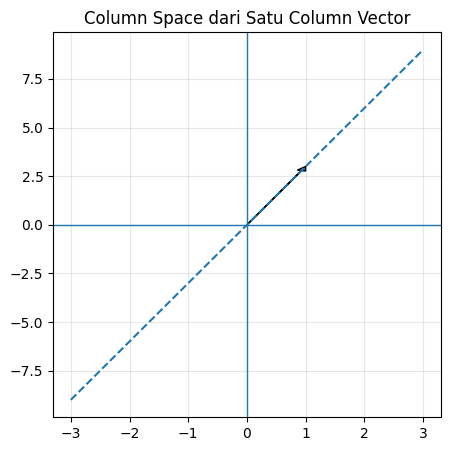

In [5]:
v = np.array([1, 3])
lambdas = np.linspace(-3, 3, 100)
points = np.outer(lambdas, v)

plt.figure(figsize=(5, 5))
plt.plot(points[:, 0], points[:, 1], linestyle="--")
plt.arrow(0, 0, v[0], v[1], head_width=.15, length_includes_head=True)
plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.grid(alpha=0.3)
plt.title("Column Space dari Satu Column Vector")
plt.show()

## Column Space dengan Beberapa Columns

Jika matrix memiliki lebih dari satu column, column space dibentuk oleh seluruh kombinasi linear dari columns tersebut.

Contoh:

$$
C
\left(
\begin{bmatrix}
1 & 1 \\
3 & 2
\end{bmatrix}
\right)
=
\lambda_1
\begin{bmatrix}
1 \\
3
\end{bmatrix}
+
\lambda_2
\begin{bmatrix}
1 \\
2
\end{bmatrix},
\quad
\lambda \in \mathbb{R}
$$

Jika columns linearly independent dan berada di $\mathbb{R}^2$, maka column space dapat mencakup seluruh $\mathbb{R}^2$.

## Row Space

Row space adalah konsep yang sama dengan column space, tetapi menggunakan rows dari matrix.

$$
R(A)=C(A^T)
$$

Keterangan:

- $R(A)$ = row space dari matrix $A$
- $C(A^T)$ = column space dari transpose matrix $A$

Karena transpose menukar rows dan columns, row space matrix sama dengan column space dari transpose matrix tersebut.

## Null Space

Null space berbeda dari column space. Column space dapat diringkas dengan pertanyaan:

$$
Ax=b
$$

Sedangkan null space diringkas dengan:

$$
Ay=0
$$

Keterangan:

- $A$ = matrix
- $y$ = vector coefficient
- $0$ = zeros vector
- $N(A)$ = null space dari matrix $A$

Null space berisi vector nonzero yang membuat linear combination dari columns matrix menghasilkan zeros vector. Solusi $y=0$ selalu ada, tetapi disebut trivial solution dan tidak dihitung sebagai null space yang menarik.

In [6]:
A = np.array([
    [1, -1],
    [-2, 2]
])

B = np.array([
    [1, -1],
    [-2, 3]
])

if SCIPY_AVAILABLE:
    print("Null space of A:")
    print(scipy.linalg.null_space(A))

    print("\nNull space of B:")
    print(scipy.linalg.null_space(B))
else:
    print("SciPy tidak tersedia di environment ini.")

Null space of A:
[[0.70710678]
 [0.70710678]]

Null space of B:
[]


## Interpretasi Null Space

Pada matrix pertama, columns-nya dependent, sehingga terdapat nontrivial null space. Pada matrix kedua, columns-nya independent, sehingga null space-nya empty set.

Poin penting chapter:

- Full-rank atau full column-rank matrices memiliki empty null space.
- Reduced-rank matrices memiliki nontrivial null space.
- Null space penting untuk memahami eigenvectors dan singular vectors pada chapter berikutnya.

## Rank

Rank adalah bilangan nonnegatif yang dimiliki setiap matrix. Rank berkaitan dengan jumlah informasi unik dalam matrix.

Beberapa properti rank:

| Properti | Penjelasan |
|---|---|
| Nonnegative integer | Rank bernilai 0, 1, 2, dan seterusnya. |
| Unique | Setiap matrix hanya memiliki satu rank. |
| Maksimum | Rank maksimum adalah $\min(M,N)$. |
| Full-rank | Matrix memiliki rank maksimum. |
| Reduced-rank / singular | Rank lebih kecil dari maksimum. |
| Scalar multiplication | Tidak mengubah rank, kecuali dikalikan 0. |

## Definisi dan Interpretasi Rank

Rank memiliki beberapa interpretasi yang ekuivalen:

- Jumlah columns terbesar yang membentuk linearly independent set.
- Jumlah rows terbesar yang membentuk linearly independent set.
- Dimensionality dari column space.
- Dimensionality dari row space.
- Jumlah dimensi yang mengandung informasi dalam matrix.
- Jumlah singular values yang nonzero.

Secara ringkas:

$$
r(A) \le \min(M,N)
$$

Keterangan:

- $r(A)$ = rank dari matrix $A$
- $M$ = jumlah rows
- $N$ = jumlah columns

In [7]:
A = np.array([
    [1, 1, -4],
    [2, -2, 2]
])

print("Shape:", A.shape)
print("Rank:", np.linalg.matrix_rank(A))

Shape: (2, 3)
Rank: 2


## Rank of Special Matrices

Chapter ini menjelaskan rank untuk beberapa special matrices.

| Matrix | Rank |
|---|---|
| Vector nonzero | 1 |
| Zeros matrix | 0 |
| Identity matrix $I_N$ | $N$ |
| Diagonal matrix | Jumlah diagonal elements yang nonzero |
| Triangular matrix | Full-rank jika semua diagonal elements nonzero |
| Random floating-point matrix | Hampir pasti memiliki rank maksimum |
| Rank-1 matrix | Memiliki satu column atau row worth of information |

In [8]:
I = np.eye(4)
Z = np.zeros((4, 4))
D = np.diag([1, 0, 3, 4])
R = np.random.randn(5, 3)

print("Rank identity:", np.linalg.matrix_rank(I))
print("Rank zeros:", np.linalg.matrix_rank(Z))
print("Rank diagonal:", np.linalg.matrix_rank(D))
print("Rank random:", np.linalg.matrix_rank(R))

Rank identity: 4
Rank zeros: 0
Rank diagonal: 3
Rank random: 3


## Rank-1 Matrices

Rank-1 matrix hanya memiliki satu dimensi informasi. Semua columns atau rows merupakan scaled copies.

Salah satu cara membuat rank-1 matrix adalah melalui outer product dua nonzero vectors.

$$
A = uv^T
$$

Keterangan:

- $u$ = column vector
- $v^T$ = row vector
- $A$ = matrix hasil outer product
- Matrix hasilnya memiliki rank 1 jika kedua vector nonzero.

In [9]:
u = np.array([[4], [2], [3]])
v = np.array([[3, 1, 1, 3, 1]])

A_rank1 = u @ v

print(A_rank1)
print("Rank:", np.linalg.matrix_rank(A_rank1))

[[12  4  4 12  4]
 [ 6  2  2  6  2]
 [ 9  3  3  9  3]]
Rank: 1


## Rank of Added and Multiplied Matrices

Rank dari matrix hasil penjumlahan atau perkalian tidak bisa diketahui secara pasti hanya dari rank matrix asal. Namun, ada batas atas.

### Rumus Rank of Added Matrices

$$
rank(A+B) \le rank(A) + rank(B)
$$

### Rumus Rank of Product Matrices

$$
rank(AB) \le \min(rank(A), rank(B))
$$

Poin pentingnya: rank matrix hasil perkalian tidak bisa lebih besar dari rank terbesar yang diizinkan oleh matrix pengalinya.

## Rank of Shifted Matrices

Shifting square matrix dilakukan dengan menambahkan scalar pada diagonal:

$$
A + \lambda I
$$

Chapter menjelaskan bahwa shifted matrices cenderung menjadi full-rank. Salah satu tujuan shifting adalah menaikkan rank dari reduced-rank menjadi full-rank.

Shifting juga penting untuk matrix inverse, eigenvalues, dan regularization.

In [10]:
A = np.array([
    [1, 3, 2],
    [5, 7, 2],
    [2, 2, 0]
])

shifted = A + .01*np.eye(3)

print("Rank A:", np.linalg.matrix_rank(A))
print("Rank shifted:", np.linalg.matrix_rank(shifted))

Rank A: 2
Rank shifted: 3


## Theory and Practice: Tolerance dalam Rank

Secara teori, rank adalah konsep yang pasti. Namun dalam praktik komputasi, rank diestimasi dengan tolerance.

NumPy menghitung rank dengan menghitung singular values yang lebih besar dari threshold tertentu. Hal ini dilakukan karena:

- komputer memiliki rounding error,
- data bisa mengandung noise kecil,
- nilai yang sangat kecil kadang dianggap effectively zero.

Konsep tolerance ini penting dalam data cleaning, compression, dan dimension reduction.

## Rank Applications: In the Column Space?

Salah satu aplikasi rank adalah mengecek apakah vector $v$ berada dalam column space matrix $A$.

Algoritmanya:

1. Augment matrix $A$ dengan vector $v$.
2. Hitung rank matrix awal $A$.
3. Hitung rank augmented matrix.
4. Bandingkan hasilnya.

Jika rank tidak berubah, maka $v$ berada di column space $A$. Jika rank meningkat, maka $v$ tidak berada di column space $A$.

## Rumus Column Space Test

Jika matrix augmented ditulis sebagai:

$$
\tilde{A} =
\begin{bmatrix}
A & v
\end{bmatrix}
$$

maka:

$$
rank(A)=rank(\tilde{A})
\Rightarrow
v \in C(A)
$$

dan:

$$
rank(A)<rank(\tilde{A})
\Rightarrow
v \notin C(A)
$$

Keterangan:

- $C(A)$ = column space matrix $A$
- $\tilde{A}$ = matrix hasil augmentasi
- $v$ = vector yang diuji

In [11]:
A = np.array([
    [1, 2],
    [3, 6],
    [2, 4]
])

v_in = np.array([[3], [9], [6]])
v_out = np.array([[1], [0], [1]])

A_aug_in = np.hstack([A, v_in])
A_aug_out = np.hstack([A, v_out])

print("Rank A:", np.linalg.matrix_rank(A))
print("Rank [A v_in]:", np.linalg.matrix_rank(A_aug_in))
print("Rank [A v_out]:", np.linalg.matrix_rank(A_aug_out))

Rank A: 1
Rank [A v_in]: 1
Rank [A v_out]: 2


## Linear Independence of a Vector Set

Rank juga digunakan untuk menentukan apakah sebuah vector set linearly independent.

Algoritmanya:

1. Susun vectors menjadi matrix.
2. Hitung rank matrix.
3. Bandingkan rank dengan jumlah columns.

Jika rank sama dengan jumlah columns, maka columns independent. Jika rank lebih kecil, maka columns dependent.

In [12]:
A_independent = np.array([
    [1, 0],
    [0, 1],
    [2, 3]
])

A_dependent = np.array([
    [1, 2],
    [3, 6],
    [2, 4]
])

print("Rank independent matrix:", np.linalg.matrix_rank(A_independent))
print("Number of columns:", A_independent.shape[1])

print("\nRank dependent matrix:", np.linalg.matrix_rank(A_dependent))
print("Number of columns:", A_dependent.shape[1])

Rank independent matrix: 2
Number of columns: 2

Rank dependent matrix: 1
Number of columns: 2


## Determinant

Determinant adalah angka yang terkait dengan square matrix. Determinant tidak didefinisikan untuk rectangular matrix.

Dua poin terpenting dari chapter:

- Determinant hanya ada untuk square matrix.
- Determinant bernilai 0 untuk singular atau reduced-rank matrix.

Determinant ditulis sebagai:

$$
det(A)
$$

atau:

$$
|A|
$$

Single vertical bars digunakan untuk determinant, sedangkan double vertical bars digunakan untuk norm.

## Rumus Determinant Matrix 2 × 2

Untuk matrix:

$$
A =
\begin{bmatrix}
a & b \\
c & d
\end{bmatrix}
$$

determinant-nya adalah:

$$
det(A)=ad-bc
$$

Keterangan:

- $ad$ = product diagonal utama
- $bc$ = product off-diagonal
- Hasil determinant dapat positif, negatif, atau nol.

In [13]:
A = np.array([
    [2, 3],
    [4, 5]
])

det_manual = A[0,0]*A[1,1] - A[0,1]*A[1,0]
det_numpy = np.linalg.det(A)

print("Manual determinant:", det_manual)
print("NumPy determinant :", det_numpy)

Manual determinant: -2
NumPy determinant : -2.0


## Determinant dengan Linear Dependencies

Reduced-rank matrix memiliki determinant 0. Untuk matrix 2 × 2 dengan column kedua sebagai scaled version dari column pertama:

$$
\begin{vmatrix}
a & \lambda a \\
c & \lambda c
\end{vmatrix}
=
a\lambda c - \lambda ac
=
0
$$

Artinya, jika ada linear dependency pada columns, matrix menjadi singular dan determinant-nya nol.

In [14]:
A_singular = np.array([
    [1, 2],
    [3, 6]
])

A_full = np.array([
    [1, 2],
    [3, 7]
])

print("Rank singular:", np.linalg.matrix_rank(A_singular))
print("Det singular :", np.linalg.det(A_singular))

print("\nRank full:", np.linalg.matrix_rank(A_full))
print("Det full :", np.linalg.det(A_full))

Rank singular: 1
Det singular : 0.0

Rank full: 2
Det full : 0.9999999999999991


## Characteristic Polynomial

Characteristic polynomial diperkenalkan sebagai pengantar menuju eigenvalues. Ide dasarnya adalah shifting matrix dengan $\lambda I$, lalu menghitung determinant.

Untuk square matrix $A$:

$$
det(A-\lambda I)=0
$$

Keterangan:

- $A$ = square matrix
- $\lambda$ = scalar
- $I$ = identity matrix
- Solusi $\lambda$ dari persamaan ini adalah eigenvalues dari matrix $A$

Chapter ini hanya memperkenalkan ide tersebut secara awal. Pembahasan eigenvalues dilakukan lebih lengkap pada Chapter 13.

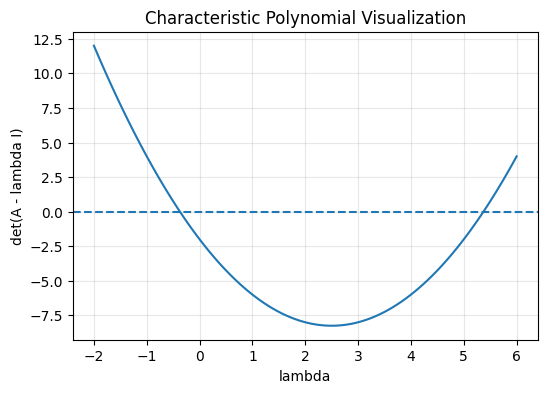

In [15]:
A = np.array([
    [1, 2],
    [3, 4]
])

# Contoh menghitung determinant dari shifted matrix untuk beberapa lambda
lambdas = np.linspace(-2, 6, 100)
dets = []

for lam in lambdas:
    dets.append(np.linalg.det(A - lam*np.eye(2)))

plt.figure(figsize=(6, 4))
plt.plot(lambdas, dets)
plt.axhline(0, linestyle="--")
plt.xlabel("lambda")
plt.ylabel("det(A - lambda I)")
plt.title("Characteristic Polynomial Visualization")
plt.grid(alpha=0.3)
plt.show()

## Ringkasan Konsep Penting

| Konsep | Ringkasan |
|---|---|
| Matrix norm | Angka yang menggambarkan matrix. |
| Frobenius norm | Square root dari jumlah seluruh elemen matrix yang dikuadratkan. |
| Trace | Jumlah diagonal elements dari square matrix. |
| Column space | Semua linear combinations dari columns matrix. |
| Row space | Semua linear combinations dari rows matrix. |
| Null space | Vector nonzero yang membuat $Ay=0$. |
| Rank | Jumlah dimensi informasi atau jumlah independent rows/columns. |
| Full-rank | Rank mencapai maksimum $\min(M,N)$. |
| Reduced-rank / singular | Rank lebih kecil dari maksimum. |
| Matrix shifting | Menambahkan $\lambda I$ pada square matrix. |
| Augmented matrix | Matrix yang ditambah column baru di sisi kanan. |
| Determinant | Angka untuk square matrix; nol pada singular matrix. |
| Characteristic polynomial | $det(A-\lambda I)=0$, pengantar eigenvalues. |

## Kesimpulan Chapter

Chapter ini memperluas pemahaman matrix dengan memperkenalkan beberapa konsep inti dalam linear algebra tingkat lanjut. Matrix norm, khususnya Frobenius norm, digunakan untuk mengukur besar elemen matrix dan dapat digunakan sebagai ukuran jarak antar matrix.

Matrix spaces menjelaskan bagaimana columns dan rows matrix membentuk subspace melalui linear weighted combination. Null space menjadi konsep khusus karena berisi vector nonzero yang menghasilkan zeros vector saat dikalikan dengan matrix.

Rank menjadi penghubung penting antara matrix spaces dan linear independence. Rank menunjukkan banyaknya informasi unik dalam matrix. Konsep ini digunakan untuk menentukan apakah vector berada dalam column space dan apakah suatu vector set linearly independent.

Determinant diperkenalkan sebagai angka yang hanya dimiliki square matrix. Determinant bernilai nol untuk reduced-rank atau singular matrix, sehingga penting untuk memahami inverse, eigendecomposition, dan characteristic polynomial. Secara keseluruhan, chapter ini menjadi jembatan menuju topik-topik lanjutan seperti matrix inverse, least squares, eigenvalues, dan SVD.